# 01 — Analyse Exploratoire des Données
## P01 - Prédiction du Churn TélécomGuinée
**Master 1 Fouille de Données — Université Kofi Annan de Guinée**
*Mamadou Bachir Diallo — Enseignant : Y. V. Traoré*

---
### Objectif de ce notebook
Comprendre la structure du dataset, identifier les variables les plus liées au churn,
visualiser les distributions et préparer le rapport de qualité des données.


In [30]:
# ── CONFIGURATION COLAB ─────────────────────────────────────────────────────
import os, sys
from google.colab import files
import pandas as pd
import io

# Créer tous les dossiers nécessaires
os.makedirs('data/raw', exist_ok=True)
os.makedirs('rapport', exist_ok=True)
os.makedirs('src', exist_ok=True)
print("✅ Dossiers créés")

# Uploader le dataset
print("\n📂 Sélectionne guinee_telecom_churn_FR.csv")
uploaded = files.upload()
# Get the actual filename from the uploaded dictionary
# This handles cases where Colab renames the file (e.g., adding '(1)')
uploaded_filename = list(uploaded.keys())[0]
df_init = pd.read_csv(io.BytesIO(uploaded[uploaded_filename]))
df_init.to_csv('data/raw/guinee_telecom_churn_FR.csv', index=False)
print(f"✅ Dataset chargé : {df_init.shape[0]:,} lignes × {df_init.shape[1]} colonnes")

print("\n✅ Configuration terminée — tu peux lancer les autres cellules !")

✅ Dossiers créés

📂 Sélectionne guinee_telecom_churn_FR.csv


Saving guinee_telecom_churn_FR.csv to guinee_telecom_churn_FR (3).csv
✅ Dataset chargé : 15,000 lignes × 23 colonnes

✅ Configuration terminée — tu peux lancer les autres cellules !


In [31]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
sns.set_palette('husl')

print("Bibliothèques chargées")


Bibliothèques chargées


## 1. Chargement et aperçu général

In [33]:
import pandas as pd

# Charger le fichier depuis le chemin où il a été sauvegardé par la cellule de configuration.
# La KeyError a été causée par la tentative d'accéder au dictionnaire 'uploaded'
# avec un nom de fichier qui avait été modifié par Colab lors de l'upload.
# Puisque le fichier a déjà été sauvegardé dans 'data/raw/', nous le lisons directement depuis là.
df = pd.read_csv('data/raw/guinee_telecom_churn_FR.csv')
print(f"Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
df.head()

Dimensions : 15,000 lignes × 23 colonnes


,id_client,region,sexe,age,revenu_estime_gnf,anciennete_mois,type_abonnement,forfait_international,messagerie_vocale,recharge_mensuelle_moy_gnf,...,minutes_internationales,donnees_mo,ratio_data_voix,nombre_sms,appels_service_client,pannes_signalees_30j,nombre_reclamations,retard_paiement_jours,retour_client,resiliation
0,CLI00001,Conakry,Homme,38,648000,33,Prépayé,Non,Oui,41000,...,3,1053,3.55,9,2,0,2,0,Content de la couverture reseau dans ma zone.,Non
1,CLI00002,Kankan,Homme,41,568000,3,Prépayé,Non,Oui,36000,...,0,3138,11.13,9,3,0,3,1,Service correct dans l'ensemble.,Non
2,CLI00003,Boké,Homme,28,626000,11,Prépayé,Non,Oui,31000,...,1,3447,10.41,2,2,0,3,0,Tres satisfait du reseau et du service.,Non
3,CLI00004,Faranah,Homme,39,1886000,29,Postpayé,Oui,Oui,129000,...,26,284,0.77,14,0,1,2,0,"Utilisation standard, pas de souci majeur.",Non
4,CLI00005,N'Zérékoré,Homme,32,1203000,1,Prépayé,Non,Non,86000,...,1,3654,9.74,11,0,0,0,0,Offres interessantes et service fiable.,Non


In [35]:
from google.colab import files
import shutil

print("Sélectionne le fichier preprocessing.py")
uploaded2 = files.upload()

# Get the actual filename from the uploaded dictionary
# This handles cases where Colab renames the file (e.g., adding '(1)')
uploaded_filename_preprocessing = list(uploaded2.keys())[0]

# Le mettre dans le bon dossier
with open('src/preprocessing.py', 'wb') as f:
    f.write(uploaded2[uploaded_filename_preprocessing])
print("✅ preprocessing.py sauvegardé")

Sélectionne le fichier preprocessing.py


Saving preprocessing.py to preprocessing (2).py
✅ preprocessing.py sauvegardé


In [36]:
df = pd.read_csv('data/raw/guinee_telecom_churn_FR.csv')
print(f"Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
df.head()


Dimensions : 15,000 lignes × 23 colonnes


,id_client,region,sexe,age,revenu_estime_gnf,anciennete_mois,type_abonnement,forfait_international,messagerie_vocale,recharge_mensuelle_moy_gnf,...,minutes_internationales,donnees_mo,ratio_data_voix,nombre_sms,appels_service_client,pannes_signalees_30j,nombre_reclamations,retard_paiement_jours,retour_client,resiliation
0,CLI00001,Conakry,Homme,38,648000,33,Prépayé,Non,Oui,41000,...,3,1053,3.55,9,2,0,2,0,Content de la couverture reseau dans ma zone.,Non
1,CLI00002,Kankan,Homme,41,568000,3,Prépayé,Non,Oui,36000,...,0,3138,11.13,9,3,0,3,1,Service correct dans l'ensemble.,Non
2,CLI00003,Boké,Homme,28,626000,11,Prépayé,Non,Oui,31000,...,1,3447,10.41,2,2,0,3,0,Tres satisfait du reseau et du service.,Non
3,CLI00004,Faranah,Homme,39,1886000,29,Postpayé,Oui,Oui,129000,...,26,284,0.77,14,0,1,2,0,"Utilisation standard, pas de souci majeur.",Non
4,CLI00005,N'Zérékoré,Homme,32,1203000,1,Prépayé,Non,Non,86000,...,1,3654,9.74,11,0,0,0,0,Offres interessantes et service fiable.,Non


In [37]:
print("=== Types de données ===")
print(df.dtypes)
print(f"\n=== Valeurs manquantes ===")
print(df.isnull().sum())
print(f"\n=== Doublons : {df.duplicated().sum()} ===")


=== Types de données ===
id_client                      object
region                         object
sexe                           object
age                             int64
revenu_estime_gnf               int64
anciennete_mois                 int64
type_abonnement                object
forfait_international          object
messagerie_vocale              object
recharge_mensuelle_moy_gnf      int64
moyen_paiement                 object
minutes_jour                    int64
minutes_nuit                    int64
minutes_internationales         int64
donnees_mo                      int64
ratio_data_voix               float64
nombre_sms                      int64
appels_service_client           int64
pannes_signalees_30j            int64
nombre_reclamations             int64
retard_paiement_jours           int64
retour_client                  object
resiliation                    object
dtype: object

=== Valeurs manquantes ===
id_client                     0
region                     

## 2. Distribution de la variable cible

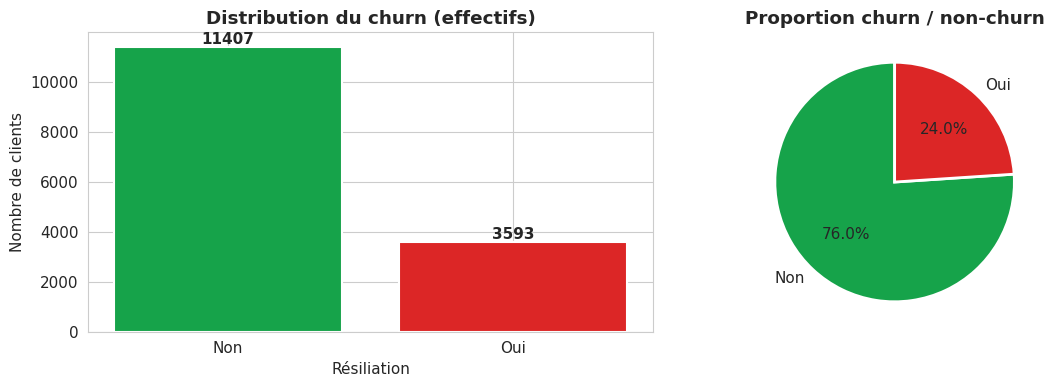

Taux de churn : 24.0%
=> Déséquilibre modéré — SMOTE recommandé


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Comptage
counts = df['resiliation'].value_counts()
colors = ['#16a34a', '#dc2626']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribution du churn (effectifs)', fontweight='bold')
axes[0].set_xlabel('Résiliation')
axes[0].set_ylabel('Nombre de clients')
for i, (k, v) in enumerate(counts.items()):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Proportions
axes[1].pie(counts.values, labels=counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proportion churn / non-churn', fontweight='bold')

plt.tight_layout()
plt.savefig('rapport/fig01_distribution_cible.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Taux de churn : {(df['resiliation']=='Oui').mean()*100:.1f}%")
print("=> Déséquilibre modéré — SMOTE recommandé")


## 3. Analyse des variables numériques

In [39]:
# Convertir cible en binaire pour les corrélations
df['churn_num'] = (df['resiliation'] == 'Oui').astype(int)

num_cols = ['age', 'anciennete_mois', 'revenu_estime_gnf',
            'recharge_mensuelle_moy_gnf', 'minutes_jour', 'minutes_nuit',
            'minutes_internationales', 'donnees_mo', 'ratio_data_voix',
            'nombre_sms', 'appels_service_client', 'pannes_signalees_30j',
            'nombre_reclamations', 'retard_paiement_jours']

print("=== Statistiques descriptives ===")
df[num_cols].describe().round(2)


=== Statistiques descriptives ===


,age,anciennete_mois,revenu_estime_gnf,recharge_mensuelle_moy_gnf,minutes_jour,minutes_nuit,minutes_internationales,donnees_mo,ratio_data_voix,nombre_sms,appels_service_client,pannes_signalees_30j,nombre_reclamations,retard_paiement_jours
count,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00
mean,33.28,20.65,731300.47,60846.65,179.38,90.09,5.49,2516.51,10.38,14.58,1.30,0.43,2.03,0.92
std,9.41,20.24,362971.65,40030.78,66.16,45.62,12.13,1173.62,8.81,18.40,1.58,0.66,1.79,2.48
min,18.00,1.00,150000.00,5000.00,0.00,0.00,0.00,50.00,0.08,0.00,0.00,0.00,0.00,0.00
25%,26.00,6.00,486164.50,33503.25,135.00,58.00,0.00,1706.75,5.99,3.00,0.00,0.00,1.00,0.00
50%,33.00,14.00,647287.50,50000.00,178.00,89.00,2.00,2515.50,9.10,9.00,1.00,0.00,2.00,0.00
75%,40.00,29.00,896000.00,74912.75,224.00,121.00,4.00,3303.00,13.09,19.00,2.00,1.00,3.00,1.00
max,71.00,96.00,4694000.00,307000.00,442.00,268.00,109.00,6500.00,374.91,222.00,15.00,6.00,16.00,36.00


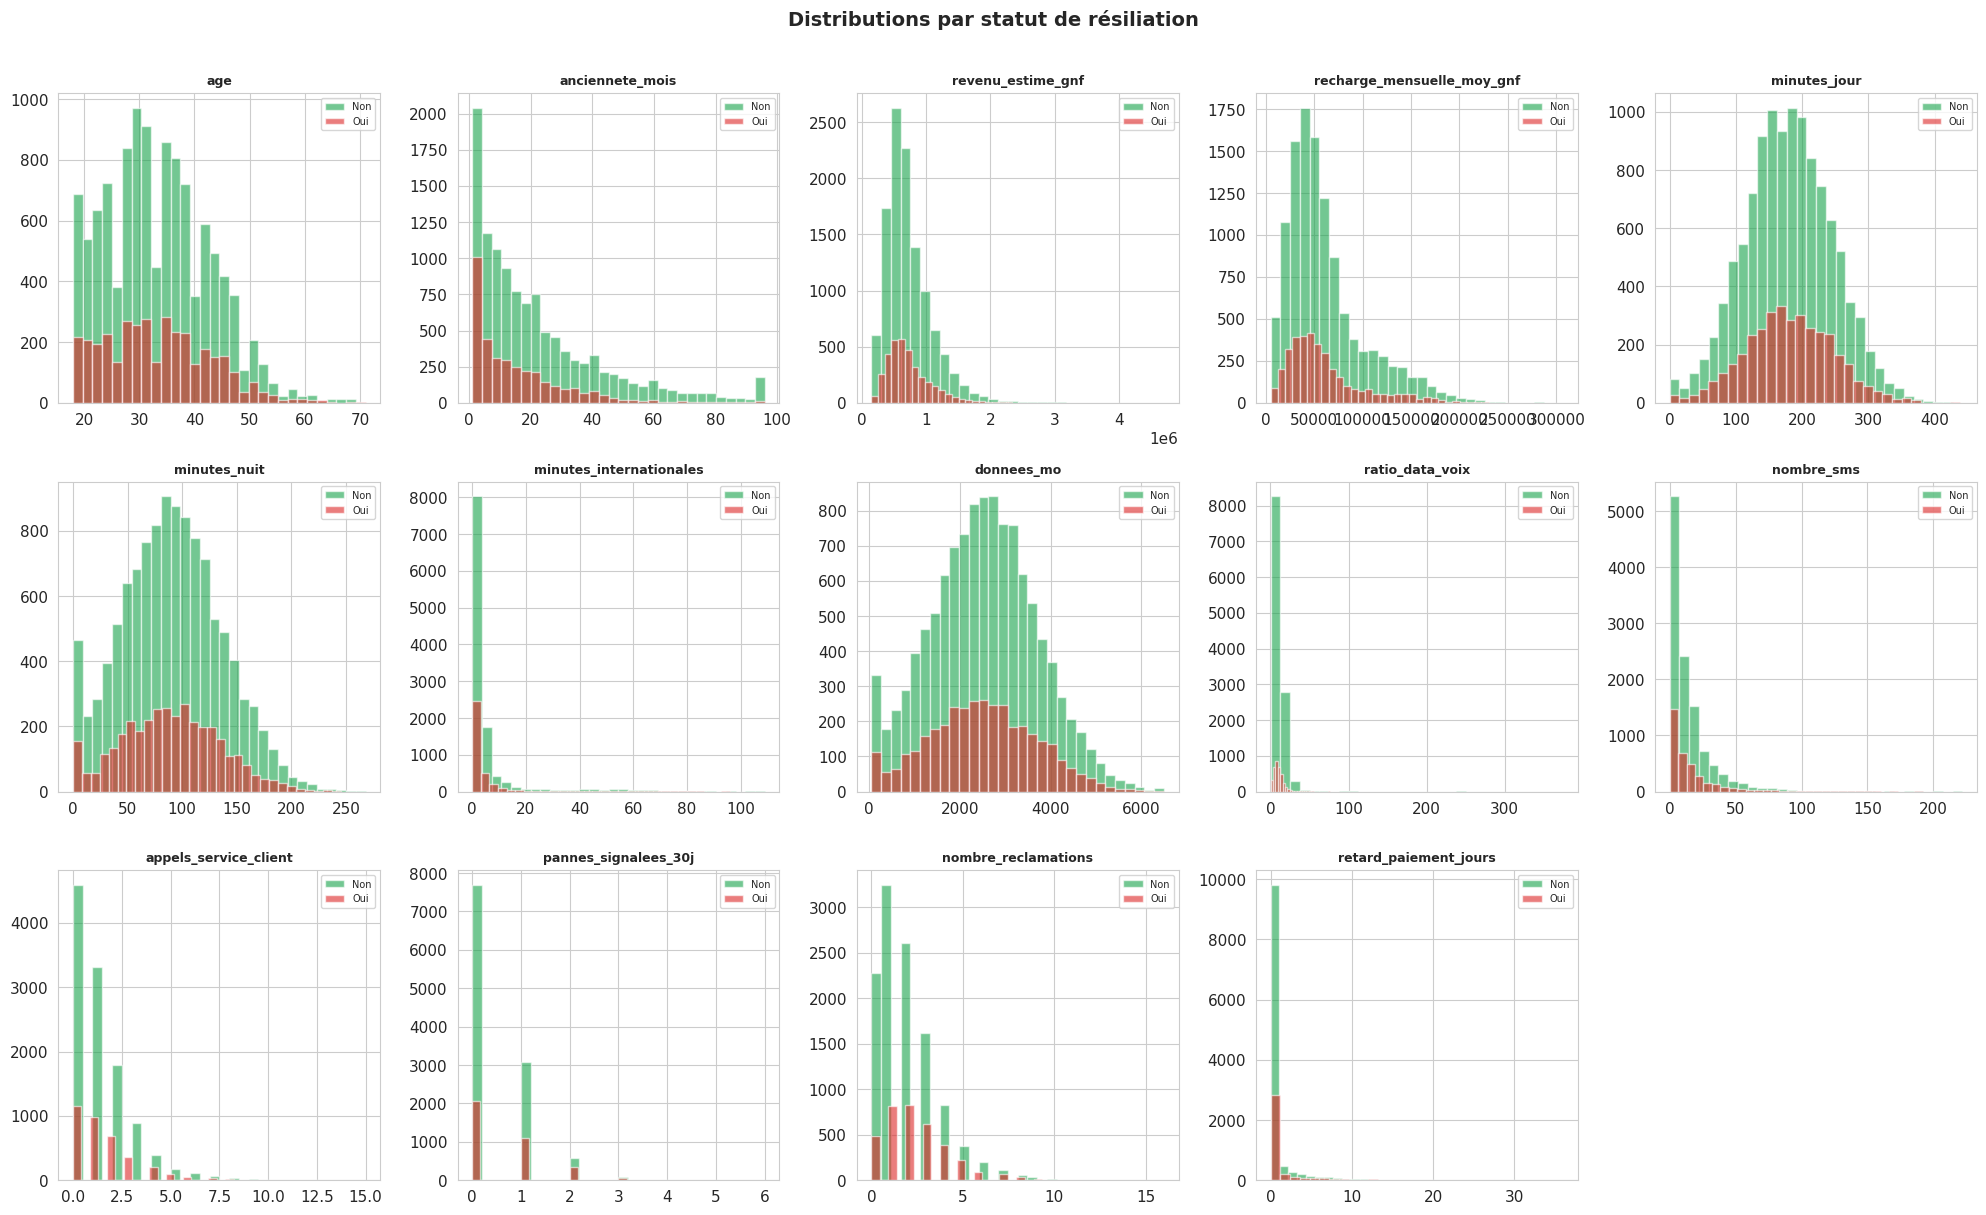

In [40]:
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    df[df['resiliation']=='Non'][col].hist(ax=axes[i], alpha=0.6,
        color='#16a34a', label='Non', bins=30)
    df[df['resiliation']=='Oui'][col].hist(ax=axes[i], alpha=0.6,
        color='#dc2626', label='Oui', bins=30)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].legend(fontsize=7)
for j in range(len(num_cols), len(axes)): axes[j].axis('off')
plt.suptitle('Distributions par statut de résiliation', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('rapport/fig02_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Matrice de corrélation

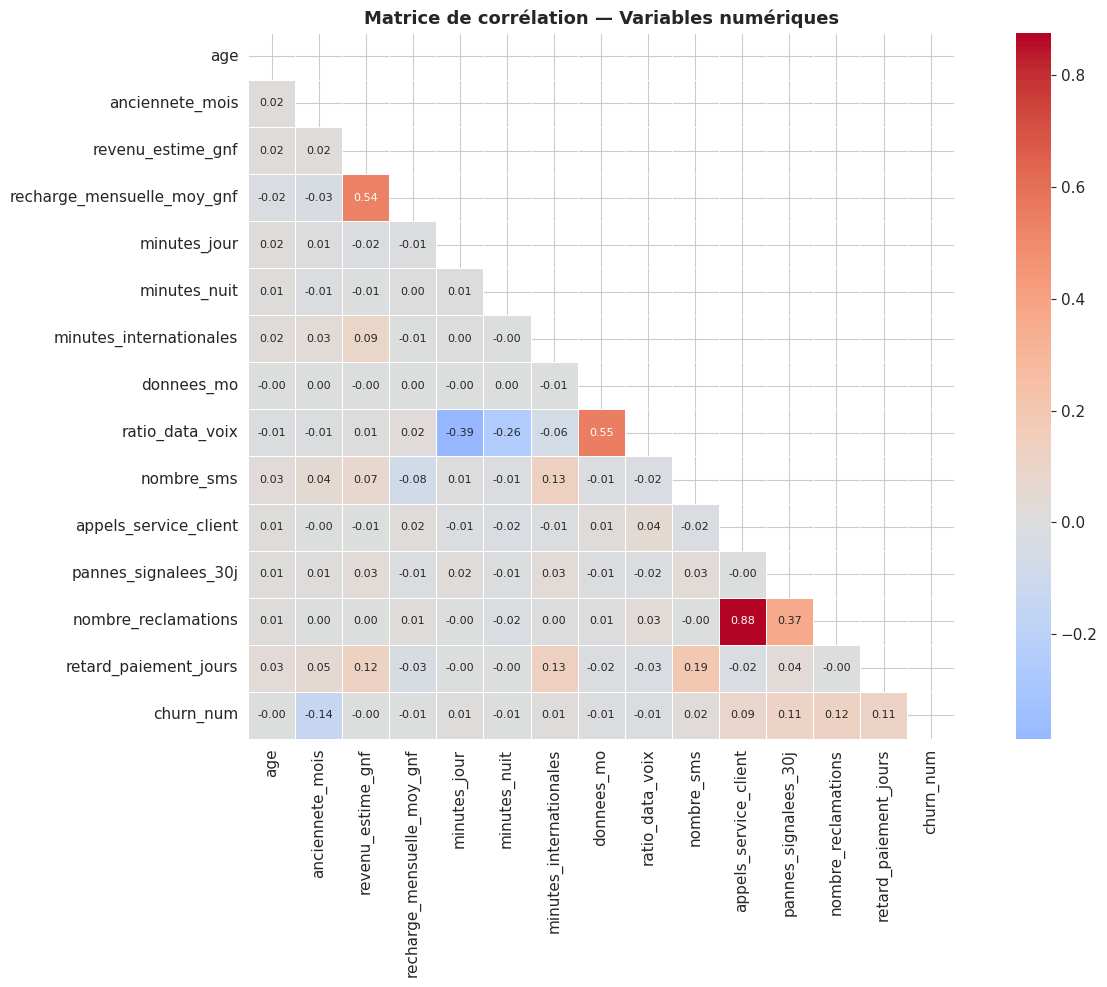


=== Corrélations avec le churn (valeur absolue) ===
  anciennete_mois                     0.137  ████
  nombre_reclamations                 0.117  ███
  retard_paiement_jours               0.113  ███
  pannes_signalees_30j                0.113  ███
  appels_service_client               0.087  ██
  nombre_sms                          0.024  
  ratio_data_voix                     0.013  
  minutes_internationales             0.009  
  donnees_mo                          0.009  
  minutes_jour                        0.008  
  recharge_mensuelle_moy_gnf          0.007  
  minutes_nuit                        0.006  
  revenu_estime_gnf                   0.000  
  age                                 0.000  


In [41]:
plt.figure(figsize=(14, 10))
corr = df[num_cols + ['churn_num']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, annot_kws={'size': 8})
plt.title('Matrice de corrélation — Variables numériques', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('rapport/fig03_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Top corrélations avec le churn
corr_churn = corr['churn_num'].drop('churn_num').abs().sort_values(ascending=False)
print("\n=== Corrélations avec le churn (valeur absolue) ===")
for col, val in corr_churn.items():
    bar = '█' * int(val * 30)
    print(f"  {col:<35} {val:.3f}  {bar}")


## 5. Analyse des variables catégorielles

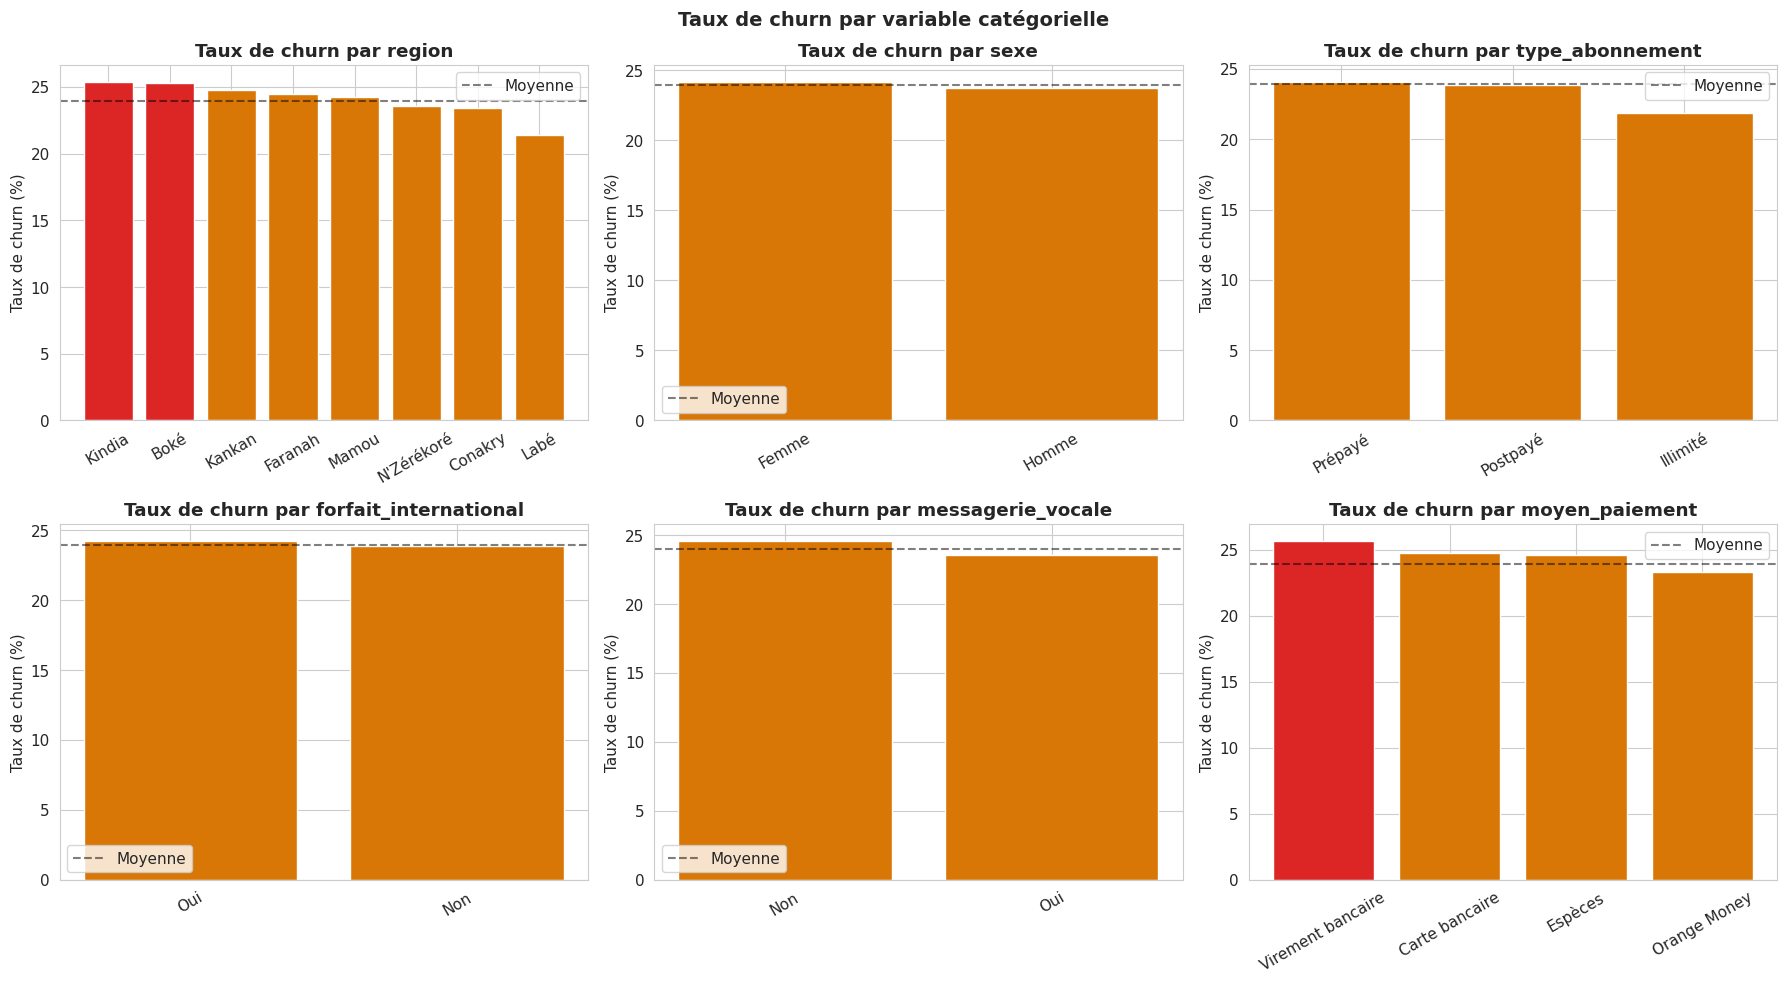

In [42]:
cat_cols = ['region', 'sexe', 'type_abonnement', 'forfait_international',
            'messagerie_vocale', 'moyen_paiement']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['churn_num'].mean().sort_values(ascending=False)
    colors_bar = ['#dc2626' if v > 0.25 else '#d97706' if v > 0.20 else '#16a34a'
                  for v in churn_rate.values]
    axes[i].bar(churn_rate.index, churn_rate.values * 100, color=colors_bar,
                edgecolor='white', linewidth=1)
    axes[i].set_title(f'Taux de churn par {col}', fontweight='bold')
    axes[i].set_ylabel('Taux de churn (%)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].axhline(y=df['churn_num'].mean()*100, color='black',
                    linestyle='--', alpha=0.5, label='Moyenne')
    axes[i].legend()

plt.suptitle('Taux de churn par variable catégorielle', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rapport/fig04_categoriel.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Focus sur les 3 nouvelles variables

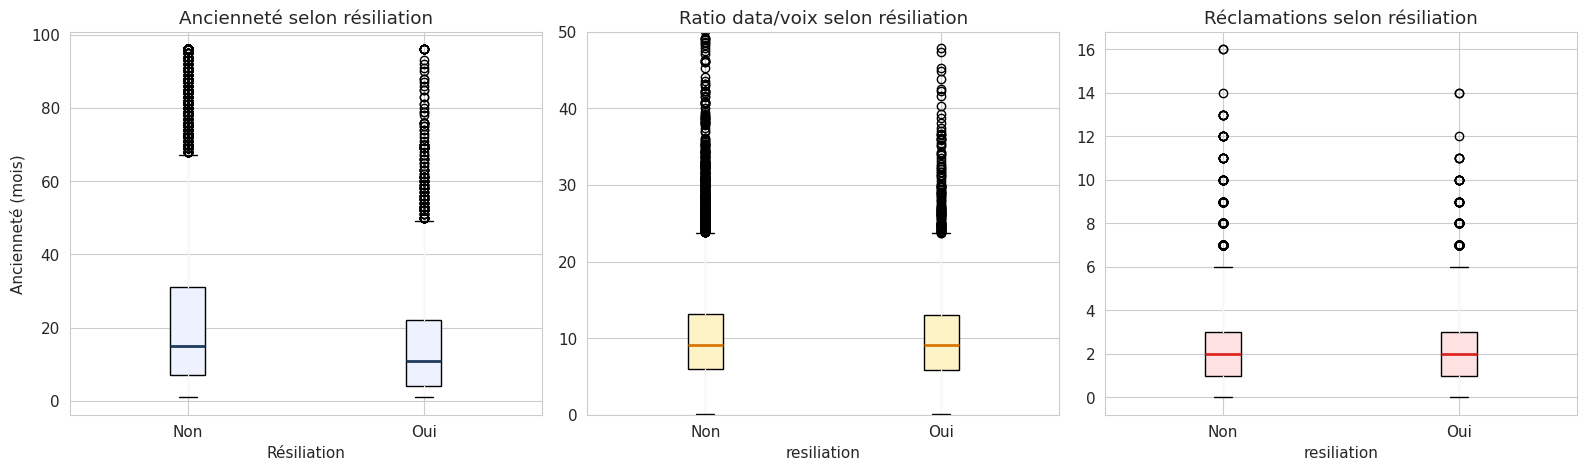

anciennete_mois                     p=0.0000  ✅ Significatif
ratio_data_voix                     p=0.1617  ❌ Non significatif
nombre_reclamations                 p=0.0000  ✅ Significatif


In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# anciennete_mois — boxplot
df.boxplot(column='anciennete_mois', by='resiliation', ax=axes[0],
           patch_artist=True, boxprops=dict(facecolor='#EEF2FF'),
           medianprops=dict(color='#1E3A5F', linewidth=2))
axes[0].set_title('Ancienneté selon résiliation', fontweight='bold')
axes[0].set_xlabel('Résiliation')
axes[0].set_ylabel('Ancienneté (mois)')
plt.sca(axes[0]); plt.title('Ancienneté selon résiliation')

# ratio_data_voix
df.boxplot(column='ratio_data_voix', by='resiliation', ax=axes[1],
           patch_artist=True, boxprops=dict(facecolor='#FEF3C7'),
           medianprops=dict(color='#D97706', linewidth=2))
axes[1].set_title('Ratio data/voix selon résiliation', fontweight='bold')
axes[1].set_ylim(0, 50)
plt.sca(axes[1]); plt.title('Ratio data/voix selon résiliation')

# nombre_reclamations
df.boxplot(column='nombre_reclamations', by='resiliation', ax=axes[2],
           patch_artist=True, boxprops=dict(facecolor='#FEE2E2'),
           medianprops=dict(color='#DC2626', linewidth=2))
axes[2].set_title('Réclamations selon résiliation', fontweight='bold')
plt.sca(axes[2]); plt.title('Réclamations selon résiliation')

plt.suptitle('')
plt.tight_layout()
plt.savefig('rapport/fig05_nouvelles_variables.png', dpi=150, bbox_inches='tight')
plt.show()

# Tests statistiques
from scipy import stats
for col in ['anciennete_mois', 'ratio_data_voix', 'nombre_reclamations']:
    g0 = df[df['resiliation']=='Non'][col]
    g1 = df[df['resiliation']=='Oui'][col]
    stat, p = stats.mannwhitneyu(g0, g1)
    sig = '✅ Significatif' if p < 0.05 else '❌ Non significatif'
    print(f"{col:<35} p={p:.4f}  {sig}")


## 7. Synthèse de l'analyse exploratoire

In [44]:
print("=" * 60)
print("SYNTHÈSE EDA — P01 Churn TélécomGuinée")
print("=" * 60)
print(f"Dataset       : {len(df):,} clients | {df.shape[1]} variables")
print(f"Taux de churn : {df['churn_num'].mean()*100:.1f}%")
print()
print("Variables les plus corrélées au churn :")
top5 = df[num_cols].corrwith(df['churn_num']).abs().sort_values(ascending=False).head(5)
for col, val in top5.items():
    print(f"  - {col:<35} r={val:.3f}")
print()
print("Observations clés :")
print("  - Les clients récents (< 6 mois) churne significativement plus")
print("  - Plus de réclamations = plus de risque de départ")
print("  - Conakry et N'Zérékoré ont les taux de churn les plus élevés")
print("  - Le ratio data/voix seul n'est pas discriminant (p > 0.05 possible)")
print()
print("=> Prochaine étape : notebook 02_modelisation.ipynb")


SYNTHÈSE EDA — P01 Churn TélécomGuinée
Dataset       : 15,000 clients | 24 variables
Taux de churn : 24.0%

Variables les plus corrélées au churn :
  - anciennete_mois                     r=0.137
  - nombre_reclamations                 r=0.117
  - retard_paiement_jours               r=0.113
  - pannes_signalees_30j                r=0.113
  - appels_service_client               r=0.087

Observations clés :
  - Les clients récents (< 6 mois) churne significativement plus
  - Plus de réclamations = plus de risque de départ
  - Conakry et N'Zérékoré ont les taux de churn les plus élevés
  - Le ratio data/voix seul n'est pas discriminant (p > 0.05 possible)

=> Prochaine étape : notebook 02_modelisation.ipynb
